<!--
Copyright 2026 EUMETSAT

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
-->

# Slot-Based Parallelism: MTG FCI L1C

Turn **two hours of FCI observations into one Zarr cube**. The recorded twelve-process
runs took **about 39 seconds**, compared with **251 seconds using one process**.

Use the public plugin with the same data window and tuning below. These timings
come from development snapshots; your hardware and software versions affect the result.

## Why DirectZarr Scales

The plugin maps each acquisition to a fixed time slot. Firecube creates the arrays
first, then each process writes its own chunk-aligned region. No shared append
position is needed. Time coordinates are prepared once; one process owns static grids.



The diagram shows the general pattern. Here, twelve processes each receive one
10-minute acquisition. [More about DirectZarr](https://eumetsat.github.io/firecube/latest/concepts/output-formats/zarr/direct-region/).

## 1. Set Up Your JupyterHub Kernel

<div class="alert alert-block alert-warning">
<p>Select a <strong>Python 3.12+ kernel on Linux</strong>. The benchmark used <strong>20 ARM CPU cores,
119 GiB RAM and local NVMe</strong>; your notebook server needs comparable resources.
Allow <strong>100 GB free</strong> for inputs, scratch files and output.
Install below, then restart the kernel before continuing.</p>
</div>

In [ ]:
%pip install -r https://eumetsat.github.io/firecube/latest/showcase/benchmark-requirements.txt

In [ ]:
import json
import os
import re
import sys
import tempfile
import time
from pathlib import Path

os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ["PATH"]
source = Path("inputs/fci").resolve()
grids = Path("fci_grids.npz").resolve()
output = Path("outputs/fci-benchmarks").resolve()
output.mkdir(parents=True, exist_ok=True)

## 2. Get The Data

With [EUMDAC credentials configured](https://user.eumetsat.int/resources/user-guides/eumetsat-data-access-client-eumdac),
download **12 FDHSI products for 1 July 2025, 00:00–02:00 UTC** (about 6 GB).
Skip the download if the ZIPs are already in `inputs/fci`.

In [ ]:
!eumdac download \
    -c EO:EUM:DAT:0662 \
    -s 2025-07-01T00:00:00 \
    -e 2025-07-01T01:59:59 \
    --limit 12 \
    -o "{source}" \
    --integrity
assert _exit_code == 0, "eumdac download failed - see the output above"

In [ ]:
files = sorted(source.glob("*.zip"))
expected = [f"20250701{s // 6:02d}{s % 6 * 10:02d}" for s in range(12)]
timestamps = [re.search(r"_OPE_(\d{12})\d{2}_", p.name) for p in files]
assert all("FCI-1C-RRAD-FDHSI" in p.name for p in files)
assert all(timestamps) and sorted(m[1] for m in timestamps) == expected, (
    "Expected all 12 acquisitions"
)
print(f"Ready: {len(files)} acquisitions")

## 3. Prepare The Cube

Generate shared latitude and longitude grids once. Each ingest process will reuse them.

In [ ]:
!firecube plugins mtg_fci_l1c geo generate --resolutions 1km,2km --output "{grids}"
assert _exit_code == 0, "firecube plugins mtg_fci_l1c geo generate failed - see the output above"

Choose the process count and keep the measured settings: **four extraction workers,
eight concurrent region writes, no sharding, no empty-chunk writes**.
All channels and float64 pixel time are retained. This cell creates a fresh run directory.

In [ ]:
processes = 12  # Change to 1, 2, 4 or 6 to compare scaling.
assert processes in (1, 2, 4, 6, 12)
assert grids.is_file(), "Generate the shared grids first"
run_dir = Path(tempfile.mkdtemp(prefix=f"p{processes}-", dir=output))
target = run_dir / "cube.zarr"
target_uri = target.as_uri()
scratch_dir = run_dir / "scratch"

# Every firecube command below takes these flags; {common} inserts them.
common = f"""
--target "{target_uri}"
--product-name mtg_fci_l1c
--storage-type local
--storage-driver fsspec
--write-mode direct
--option product_type=FDHSI
--option time_epoch=2025-07-01
--option time_slots=12
--option resolutions=1km,2km
--option pixel_time_dtype=float64
--option include_pixel_time=true
--option include_pixel_quality=true
--option include_calibration=true
--option include_geolocation=true
--option pipeline_workers=1
--option pipeline_batch_size=10
--option extract_workers=4
--option zarr_sharding=false
--option zarr_region_write_concurrency=8
--option zarr_write_empty_chunks=false
--option "fci_grids_file={grids}"
--option "scratch_dir={scratch_dir}"
""".split("\n")
common = " ".join(flag for flag in common if flag)
print(f"{processes} processes → {target}")

<div class="alert alert-block alert-info">
Create the arrays and time coordinates before starting the clock.
</div>

In [ ]:
!firecube zarr preallocate mtg_fci_l1c {common} \
    --input-data "{source}" \
    --slot-start 0 \
    --slot-end 12 \
    > "{run_dir}/preallocate.log" 2>&1
assert _exit_code == 0, f"firecube zarr preallocate failed - inspect {run_dir}/preallocate.log"
print("Cube ready: 12 time slots at 1 km and 2 km")

Ask Firecube for non-overlapping ranges. Both resolutions must use the same partition.

In [ ]:
slot_size = 12 // processes
!firecube zarr slots mtg_fci_l1c {common} \
    --slot-size {slot_size} \
    --no-resume \
    --format json \
    > "{run_dir}/plan.json"
assert _exit_code == 0, "firecube zarr slots failed - see the output above"
plan = json.loads((run_dir / "plan.json").read_text())
ranges = [(start, start + slot_size) for start in range(0, 12, slot_size)]
assert {g["name"] for g in plan["groups"]} == {"data_1km", "data_2km"}
for group in plan["groups"]:
    actual = sorted(
        (r["slot_start"], r["slot_end"]) for r in plan["ranges"] if r["group"] == group["name"]
    )
    assert actual == ranges and group["static_owner"]["slot_start"] == 0
print("Slot ranges (end excluded):", ranges)

## 4. Run In Parallel

Each process writes its assigned slots in both resolutions. Only the first writes
static grids. The timer covers process startup and ingestion.

In [ ]:
starts = " ".join(str(start) for start, _ in ranges)
started = time.perf_counter()
!for lo in {starts}; do \
    hi=$(expr $$lo + {slot_size}); \
    (firecube ingest mtg_fci_l1c {common} \
        --input-data "{source}" \
        --option force_reingest=true \
        --suppress-static-emission-for-non-owner \
        --static-owner-slot-start 0 \
        --slot-start $$lo \
        --slot-end $$hi \
        > "{run_dir}/slot-$$lo-$$hi.log" 2>&1 \
        || touch "{run_dir}/slot-$$lo-$$hi.failed") & \
done; wait
wall_s = time.perf_counter() - started
failed = sorted(path.name for path in run_dir.glob("slot-*.failed"))
assert not failed, f"Ingest failed: inspect {run_dir}/slot-*.log"
print(f"Ingestion: {wall_s:.2f} seconds")

Check all twelve slots and static grids before saving the timing.

In [ ]:
import pandas as pd
import zarr

!firecube zarr slots mtg_fci_l1c {common} --format json > "{run_dir}/coverage.json"
assert _exit_code == 0, "firecube zarr slots failed - see the output above"
coverage = json.loads((run_dir / "coverage.json").read_text())
assert {g["name"] for g in coverage["groups"]} == {"data_1km", "data_2km"}
assert not coverage["ranges"]
assert all(g["covered_ranges"] == [[0, 12]] for g in coverage["groups"])
cube = zarr.open_group(str(target), mode="r")
for name in ("data_1km", "data_2km"):
    assert cube[name]["counts"].shape[0] == 12
    for field in ("latitude", "longitude", "x", "y"):
        assert cube[name][field].attrs.get("firecube_static_written")
measurement = pd.DataFrame(
    [
        {
            "processes": processes,
            "slots": 12,
            "wall_s": wall_s,
            "output": str(target),
        }
    ]
)
measurement.to_csv(output / f"measurements-{run_dir.name}.csv", index=False)
print("All 12 slots complete in both groups")
measurement

To compare process counts, change `processes` in step 3 and rerun from that cell.
Each experiment keeps a separate cube; check free space between runs.

## 5. Compare Your Timing

Blue points show the recorded medians; bars show the observed ranges. Your completed
runs appear in orange. The reference has two observations per process count and four
at twelve processes.

In [1]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

recorded_csv = """observation,round,parallelism,slots_per_process,slots,wall_s,exit_status
21,1,12,1,12,40.33,0
23,1,12,1,12,39.91,0
24,1,6,2,12,51.66,0
25,1,4,3,12,68.12,0
26,1,2,6,12,125.96,0
27,1,1,12,12,250.24,0
28,2,12,1,12,38.10,0
29,2,6,2,12,50.58,0
30,2,4,3,12,68.61,0
31,2,2,6,12,126.67,0
32,2,1,12,12,251.49,0
36,1,12,1,12,37.67,0
"""
recorded = pd.read_csv(StringIO(recorded_csv))
summary = recorded.groupby("parallelism")["wall_s"].agg(["median", "min", "max", "count"])
local_files = sorted(Path("outputs/fci-benchmarks").glob("measurements-*.csv"))
yours = pd.concat([pd.read_csv(p) for p in local_files], ignore_index=True) if local_files else None

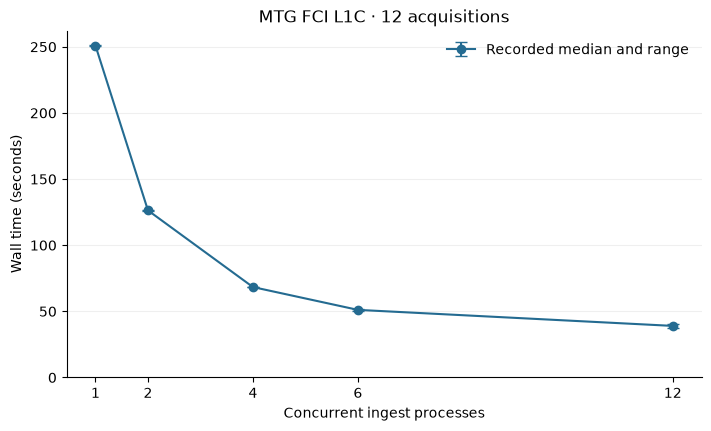

In [2]:
figure, axis = plt.subplots(figsize=(7, 4.2), layout="constrained")
axis.errorbar(
    summary.index,
    summary["median"],
    yerr=[summary["median"] - summary["min"], summary["max"] - summary["median"]],
    fmt="o-",
    capsize=4,
    color="#246b91",
    label="Recorded median and range",
)
if yours is not None:
    axis.scatter(
        yours["processes"], yours["wall_s"], color="#cd592a", marker="x", s=70, label="Your runs"
    )
axis.set(
    title="MTG FCI L1C · 12 acquisitions",
    xlabel="Concurrent ingest processes",
    ylabel="Wall time (seconds)",
    ylim=(0, None),
    xticks=summary.index,
)
axis.spines[["top", "right"]].set_visible(False)
axis.grid(axis="y", alpha=0.2)
axis.legend(frameon=False)
plt.show()

If a run fails, inspect its `slot-*.log` before comparing timings. If memory is tight,
start with `processes = 2` in a fresh run directory.

[Plugin guide](https://github.com/eumetsat/firecube-mtg-fci-l1c) ·
[Parallel Zarr writes](https://eumetsat.github.io/firecube/latest/concepts/output-formats/zarr/parallel-writes/)

MTG FCI Level 1C data (1 July 2025), distributed by EUMETSAT: Copyright 2025 EUMETSAT, CC BY 4.0. Notebook code and charts: Copyright 2026 EUMETSAT, Apache-2.0.